# EE-411 Lottery Ticket Hypothesis - Figures: Resnet-18 + Iterative + Random Init

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.16]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_create_figures_3_trials"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_create_figures_3_trials_20260116_022510
Results will be saved to: ../../results/resnet20_create_figures_3_trials_20260116_022510


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Generate Figures

Plotting 10k...
Plotting 20k...
Plotting 30k...
Saved complete plot to ../../results/resnet20_create_figures_3_trials_20260116_022510/figures/reproduced_figure_8_3trials_errorbars_resnet20_create_figures_3_trials_20260116_022510.png


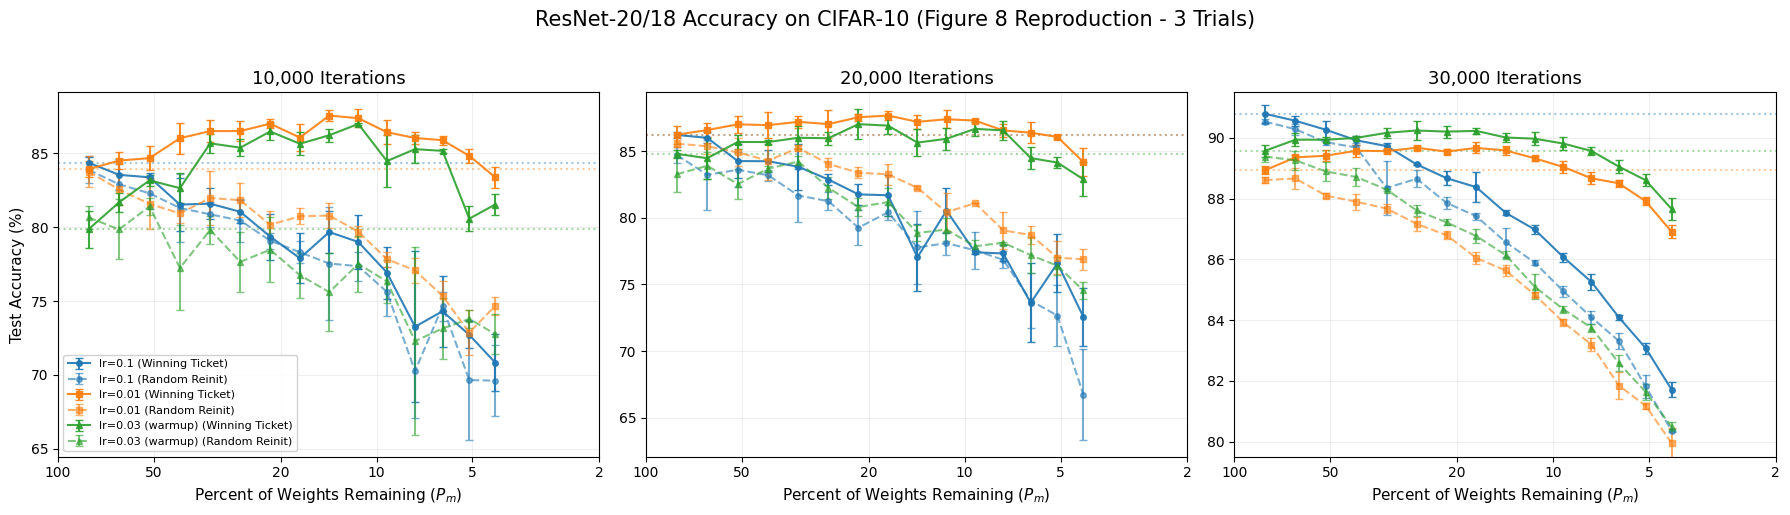

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 0. Define File Paths (Updated for 3-Trial Data)
# ==========================================

# 1. LR = 0.1 (Standard, Blue)
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth"

# 2. LR = 0.01 (Low LR, Orange)
path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.01_3_trials_20260114_033930.pth"

# 3. LR = 0.03 + Warmup (Proposed, Green)
path_iter_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924.pth"
path_rand_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924/checkpoints/random_init_results_resnet20_iterative_random_init_LR_0.03_warmup_3_trials_20260115_103924.pth"

# Define Epoch mapping indices
# 10k iters ~ epoch 29 (idx 28), 20k iters ~ epoch 57 (idx 56), 30k iters = Final
EPOCH_INDICES = {
    '10k': 28, 
    '20k': 56, 
    '30k': -1 # Last epoch
}

# ==========================================
# 1. Data Extraction Helper Functions
# ==========================================

def extract_history_acc(history, epoch_idx):
    """Helper to safely extract accuracy from history dict/list at specific index."""
    if history is None: return None
    acc_list = None
    possible_keys = ['test_accuracy', 'test_acc', 'val_accuracy', 'val_acc', 'accuracy', 'acc']
    
    if isinstance(history, dict):
        for k in possible_keys:
            if k in history:
                acc_list = history[k]; break
    elif isinstance(history, list):
        acc_list = history
        
    if acc_list is None or len(acc_list) == 0: return None
    
    # Handle negative index or out of bounds
    if epoch_idx == -1: return acc_list[-1]
    if epoch_idx >= len(acc_list): return acc_list[-1]
    
    return acc_list[epoch_idx]

def load_aggregated_data(path, step_name):
    """
    Loads 3-trial data, calculates Mean and Std for each pruning round.
    Returns: x (sparsity), y_mean (accuracy), y_std (error)
    """
    if not os.path.exists(path):
        print(f"Warning: File not found: {path}")
        return [], [], []
    
    try:
        checkpoint = torch.load(path, map_location='cpu')
        
        # Check if keys exist (handle different saving formats)
        if isinstance(checkpoint, dict):
            if 'trials' in checkpoint:
                trials_data = checkpoint['trials'] # List[List[Dict]]
            elif 'results' in checkpoint:
                trials_data = [checkpoint['results']] # Fallback for single trial format
            else:
                # Direct list
                trials_data = checkpoint if isinstance(checkpoint, list) else []
        else:
            trials_data = checkpoint

        # If data is empty
        if not trials_data:
            return [], [], []

        n_rounds = len(trials_data[0])
        
        x_list = []
        y_mean_list = []
        y_std_list = []

        target_idx = EPOCH_INDICES[step_name]

        # Iterate through each round (0 to 14)
        for r_idx in range(n_rounds):
            
            # 1. Get X-axis (Sparsity) - assume same for all trials
            pct = trials_data[0][r_idx].get('remaining_params_pct', None)
            if pct is None: continue
            
            # 2. Get Y-axis (Accuracy) from ALL trials for this round
            accuracies = []
            for trial in trials_data:
                res = trial[r_idx]
                
                if step_name == '30k':
                    # For final step, use the stored final test_accuracy
                    acc = res.get('test_accuracy', None)
                else:
                    # For intermediate steps (10k/20k), look into history
                    acc = extract_history_acc(res.get('history'), target_idx)
                
                if acc is not None:
                    accuracies.append(acc)
            
            # 3. Calculate Stats if we have data
            if len(accuracies) > 0:
                x_list.append(pct)
                y_mean_list.append(np.mean(accuracies))
                y_std_list.append(np.std(accuracies))
                
        return np.array(x_list), np.array(y_mean_list), np.array(y_std_list)

    except Exception as e:
        print(f"Error loading {path}: {e}")
        import traceback
        traceback.print_exc()
        return [], [], []

# ==========================================
# 2. Plotting Logic (With Error Bars)
# ==========================================
steps = ['10k', '20k', '30k']
titles = ['10,000 Iterations', '20,000 Iterations', '30,000 Iterations']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define Colors
color_01 = 'tab:blue'      # LR=0.1
color_001 = 'tab:orange'   # LR=0.01
color_warmup = 'tab:green' # LR=0.03 + Warmup

for i, step in enumerate(steps):
    ax = axes[i]
    print(f"Plotting {step}...")
    
    # --- Load Data (Mean & Std) ---
    # LR 0.1
    x_iter_01, y_iter_01, err_iter_01 = load_aggregated_data(path_iter_01, step)
    x_rand_01, y_rand_01, err_rand_01 = load_aggregated_data(path_rand_01, step)
    
    # LR 0.01
    x_iter_001, y_iter_001, err_iter_001 = load_aggregated_data(path_iter_001, step)
    x_rand_001, y_rand_001, err_rand_001 = load_aggregated_data(path_rand_001, step)
    
    # LR 0.03 Warmup
    x_iter_warm, y_iter_warm, err_iter_warm = load_aggregated_data(path_iter_warmup, step)
    x_rand_warm, y_rand_warm, err_rand_warm = load_aggregated_data(path_rand_warmup, step)
    
    # --- Plotting with Error Bars ---
    
    # 1. LR = 0.1 (Blue)
    if len(x_iter_01) > 0:
        # Winning Ticket (Solid)
        ax.errorbar(x_iter_01, y_iter_01, yerr=err_iter_01, label='lr=0.1 (Winning Ticket)', 
                    color=color_01, fmt='o-', markersize=4, capsize=3, alpha=0.9)
        # Baseline (Dotted Line - using the unpruned mean)
        ax.axhline(y=y_iter_01[0], color=color_01, linestyle=':', alpha=0.4) 
        
    if len(x_rand_01) > 0:
        # Random Reinit (Dashed)
        ax.errorbar(x_rand_01, y_rand_01, yerr=err_rand_01, label='lr=0.1 (Random Reinit)', 
                    color=color_01, fmt='o--', markersize=4, capsize=3, alpha=0.6)

    # 2. LR = 0.01 (Orange)
    if len(x_iter_001) > 0:
        ax.errorbar(x_iter_001, y_iter_001, yerr=err_iter_001, label='lr=0.01 (Winning Ticket)', 
                    color=color_001, fmt='s-', markersize=4, capsize=3, alpha=0.9)
        ax.axhline(y=y_iter_001[0], color=color_001, linestyle=':', alpha=0.4)
        
    if len(x_rand_001) > 0:
        ax.errorbar(x_rand_001, y_rand_001, yerr=err_rand_001, label='lr=0.01 (Random Reinit)', 
                    color=color_001, fmt='s--', markersize=4, capsize=3, alpha=0.6)

    # 3. LR = 0.03 Warmup (Green)
    if len(x_iter_warm) > 0:
        ax.errorbar(x_iter_warm, y_iter_warm, yerr=err_iter_warm, label='lr=0.03 (warmup) (Winning Ticket)', 
                    color=color_warmup, fmt='^-', markersize=4, capsize=3, alpha=0.9)
        ax.axhline(y=y_iter_warm[0], color=color_warmup, linestyle=':', alpha=0.4)
        
    if len(x_rand_warm) > 0:
        ax.errorbar(x_rand_warm, y_rand_warm, yerr=err_rand_warm, label='lr=0.03 (warmup) (Random Reinit)', 
                    color=color_warmup, fmt='^--', markersize=4, capsize=3, alpha=0.6)

    # --- Axis Formatting ---
    ax.set_xscale('log')
    ax.invert_xaxis() # 100 -> 1
    
    ticks = [100, 50, 20, 10, 5, 2]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    
    ax.set_xlabel('Percent of Weights Remaining ($P_m$)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        
    ax.set_title(titles[i], fontsize=13)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # Adjust Y-axis for the final 30k plot to zoom in on the interesting area
    if i == 2:
        ax.set_ylim(bottom=79.5, top=91.5) 

# Legend only on the first plot
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)

plt.suptitle('ResNet-20/18 Accuracy on CIFAR-10 (Figure 8 Reproduction - 3 Trials)', fontsize=15, y=1.02)
plt.tight_layout()

# Save
# save_path = "reproduced_figure_8_3trials_errorbars.png"
# if 'fig_dir' in globals(): save_path = os.path.join(fig_dir, save_path)

# plt.savefig(save_path, dpi=300, bbox_inches='tight')
# print(f"Saved complete plot with error bars to {save_path}")
# plt.show()

save_name = "reproduced_figure_8_3trials_errorbars.png"
if 'fig_dir' in globals() and 'run_id' in globals():
    save_path = os.path.join(fig_dir, f"reproduced_figure_8_3trials_errorbars_{run_id}.png")
else:
    save_path = save_name

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved complete plot to {save_path}")
plt.show()